<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
epsilon = 1e-3
phi = epsilon * np.random.randn(N)
history = [phi.copy()]


In [ ]:
dt = 0.02
gamma = 0.001
lam = 0.5

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def clip_guard(phi, max_abs=1.0):
    m = np.max(np.abs(phi))
    return phi * (max_abs / m) if m > max_abs else phi

def evolve(phi):
    return phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3)

for t in range(2000):
    phi = evolve(phi)
    phi = clip_guard(phi)
    if t % 100 == 0:
        history.append(phi.copy())


In [ ]:
def localization(phi):
    energy = phi**2
    sorted_energy = np.sort(energy)[::-1]
    return np.sum(sorted_energy[:int(0.1*N)]) / np.sum(energy)

def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

loc_index = [localization(h) for h in history]
fidelity = [correlation(h, history[0]) for h in history]


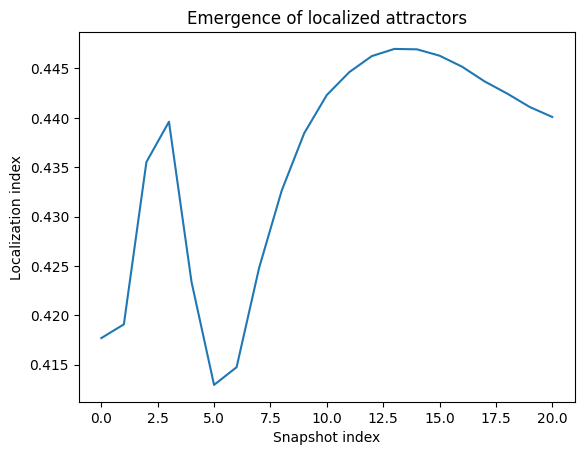

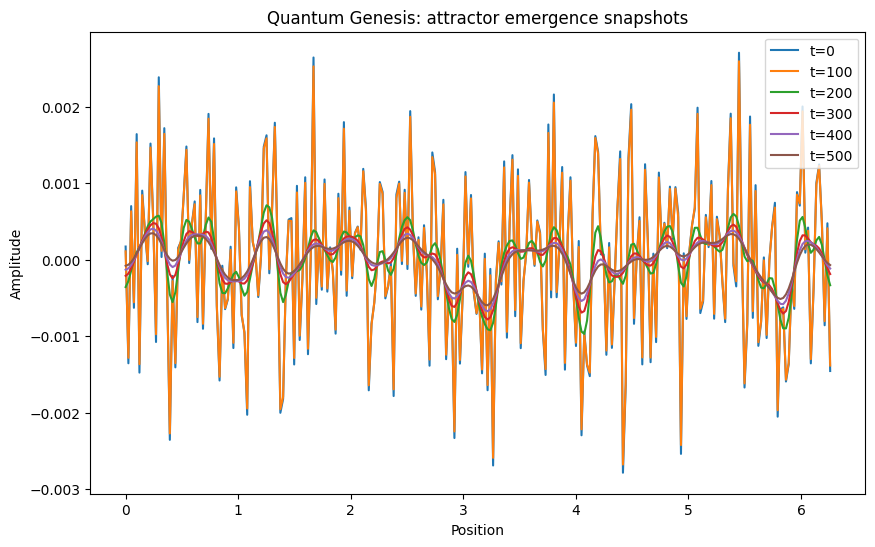

In [ ]:
# Localization index
plt.plot(loc_index)
plt.xlabel("Snapshot index")
plt.ylabel("Localization index")
plt.title("Emergence of localized attractors")
plt.show()

# Attractor snapshots
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*100}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Quantum Genesis: attractor emergence snapshots")
plt.legend()
plt.show()


In [ ]:
def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

A1 = gaussian(center=np.pi/2, width=0.2, amplitude=0.1)
A2 = gaussian(center=3*np.pi/2, width=0.2, amplitude=-0.1)
phi = A1 + A2
history = [phi.copy()]


In [ ]:
for t in range(1000):
    phi = evolve(phi)
    phi = clip_guard(phi)
    if t % 50 == 0:
        history.append(phi.copy())


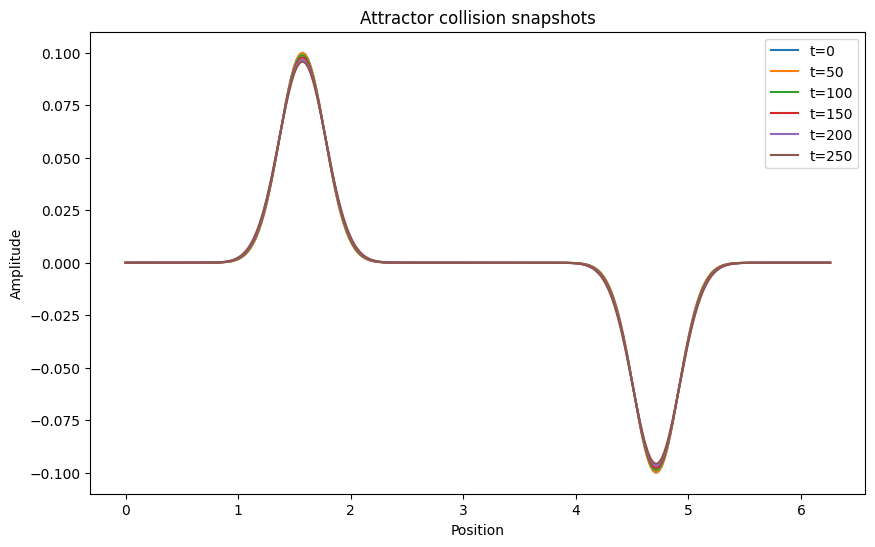

In [ ]:
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Attractor collision snapshots")
plt.legend()
plt.show()
